<a href="https://colab.research.google.com/github/LokeshGanisetti-hub/Random_Forest_Classifier/blob/main/Random_Forest_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
dataset link:"https://drive.google.com/file/d/1isrr7u_yfh69vSUAMD9oMY2P_x2YnhTu/view?usp=sharing"

**Random forest**:Random forest is a machine learning algorithm which is used for both classification and Regression task.

**Ensemble learning**:Random forest is an Ensemble learning which means it combines multiple models to improve the performance.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv("/content/customer_churn (1) (1).csv")

In [4]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
#top 10
data.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [6]:
#last 10
data.tail(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7033,9767-FFLEM,Male,0,No,No,38,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes
7035,8456-QDAVC,Male,0,No,No,19,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.1,No
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.3,No
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
data.duplicated().sum()

np.int64(0)

In [11]:
data["TotalCharges"].value_counts()  #in 1st column we are seeing null values and we need to convert this to the numeric

,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8
...,...
130.15,1
3211.9,1
7843.55,1


In [12]:
#Converting TotalCharges datatype object to numeric int

data["TotalCharges"]=pd.to_numeric(data["TotalCharges"],errors="coerce")

#coerce=Invalid values like'#$&@' etc.. will become Nan
#we dont use as type() here because i am not sure all values are valid
''' when you want to convert a column to numeric data type or datetime type

 there may be some of invalid charcters that cannot be converted to avoid the error we use this parameter'''


' when you want to convert a column to numeric data type or datetime type\n\n there may be some of invalid charcters that cannot be converted to avoid the error we use this parameter'

In [13]:
data["TotalCharges"].value_counts()

,count
TotalCharges,
20.20,11
19.75,9
19.65,8
19.90,8
20.05,8
...,...
130.15,1
3211.90,1
7843.55,1


In [14]:
data=data.dropna()

In [15]:
data.isnull().sum() #Now there is no errors ,our data is clear

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [16]:
data.info() #Total Charges colum object type is changed to numeric

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [17]:
#Droping extra columns
data.drop(columns="customerID",inplace=True)

/tmp/ipykernel_2847/3935128172.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(columns="customerID",inplace=True)


In [18]:
#Label Encoding
# most of the columns are having data type ->object
# converting the categorical columns into numerical columns----label encoding
from sklearn.preprocessing import LabelEncoder


In [19]:
le = LabelEncoder()
 #create a list with all object data type column so that you can convert to numerical

col_list = []
for i in data.columns:
  if((data[i].dtype == 'object') & (i!='Churn')):
    col_list.append(i)

col_list

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [20]:
for i in col_list:
  data[i]=le.fit_transform(data[i])

/tmp/ipykernel_2847/4207720875.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[i]=le.fit_transform(data[i])
/tmp/ipykernel_2847/4207720875.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[i]=le.fit_transform(data[i])
/tmp/ipykernel_2847/4207720875.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guid

In [21]:
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,No
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,No
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,Yes
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,No
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50,No
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90,No
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45,No
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60,Yes


In [22]:
#divide data into dependent and independent
x=data.drop(columns="Churn")
y=data["Churn"]

In [23]:
x

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60


In [24]:
y

,Churn
0,No
1,No
2,Yes
3,No
4,Yes
...,...
7038,No
7039,No
7040,No
7041,Yes


In [25]:
from sklearn.model_selection import train_test_split

In [26]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=0,stratify=y)

In [27]:
x_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
1720,0,1,0,0,2,1,0,1,0,2,0,0,2,0,0,1,0,83.80,163.70
6657,0,0,1,0,49,1,0,2,1,1,1,1,1,1,1,0,0,20.45,900.90
4957,1,0,0,0,13,1,0,2,1,1,1,1,1,1,0,1,2,20.40,251.65
4681,1,1,0,0,9,1,2,1,0,0,0,0,0,2,0,1,2,83.85,790.15
3509,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,3,44.90,44.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3061,1,1,0,0,23,1,2,1,0,2,2,0,2,2,0,1,2,106.40,2483.50
2608,1,0,1,1,7,0,1,0,2,0,0,2,0,0,0,1,2,34.50,279.25
3963,0,0,0,0,68,1,0,2,1,1,1,1,1,1,2,0,1,19.60,1441.65
6139,1,0,0,1,3,1,0,2,1,1,1,1,1,1,0,0,0,20.20,50.60


In [28]:
y_train

,Churn
1720,No
6657,No
4957,No
4681,Yes
3509,No
...,...
3061,Yes
2608,Yes
3963,No
6139,No


In [28]:
# HyperParameter -> setting/control that you choose before training the model
# n_estimators -> n number of tress
# max_depth -> maximum depth of each tree
# min_samples_split -> minimum number of samples required to split an internal node
# min_samples_leaf -> minimum number of samples required to be at a leaf node
# criterian -> gini and entropy
'''Entropy-->A measure of uncertainty or impurity in a dataset.
Gini-->Another measure of impurity, based on probability of misclassification.'''


In [29]:
#Model trainig

In [32]:
from random import random
from sklearn.ensemble import RandomForestClassifier

In [37]:
#training the data
model1=RandomForestClassifier(n_estimators=100)
model1.fit(x_train,y_train)


RandomForestClassifier()

In [38]:
#Testing the data
ans=model1.predict(x_test)

In [41]:
#Measuring Accuracy
from sklearn.metrics import *
accuracy_score(ans,y_test)*100

79.35153583617748

In [43]:
cm=confusion_matrix(ans,y_test)
cm

array([[1180,  252],
       [ 111,  215]])

In [44]:
1180+215

1395

In [45]:
# use different values for n_estimators
n=[100,30,50,300,200,500,600,150,220,350]
accuracy=[]
for i in n:
  model2=RandomForestClassifier(n_estimators=i)
  model2.fit(x_train,y_train)
  ans=model2.predict(x_test)
  acc=accuracy_score(ans,y_test)
  accuracy.append(acc)

In [46]:
#Accuracy score of 10 different trees
accuracy

[0.7895335608646189,
 0.785551763367463,
 0.7935153583617748,
 0.7889647326507395,
 0.7946530147895335,
 0.7895335608646189,
 0.7901023890784983,
 0.7878270762229806,
 0.78839590443686,
 0.7935153583617748]

#Grid Search cv
'''GridSearchCV is a tool in scikit-learn that helps you find the best hyperparameters
 for a machine learning model.'''

It works by:

1.Taking a model (e.g., DecisionTree, RandomForest).

2.Taking a param_grid (dictionary of hyperparameters and values to test).

3.Training the model on all possible combinations of those hyperparameters.

4.Using cross-validation (CV) to evaluate each combination.

5.Returning the best parameters and their performance.


estimator → the model itself (e.g., RandomForestClassifier).

n_estimators → a parameter inside that model (how many trees to build).
> Add blockquote



In [49]:
from sklearn.model_selection import GridSearchCV

param_grid={
    "n_estimators":[100,200,300],
    "min_samples_leaf":[1,2,4],
    "min_samples_split":[2,5,10],
    "max_depth":[None,5,10],
    "criterion":['gini','entropy']
}

In [50]:
model3=RandomForestClassifier(random_state=0)
grid_search=GridSearchCV(estimator=model3,param_grid=param_grid,cv=2)
grid_search.fit(x_train,y_train)

GridSearchCV(cv=2, estimator=RandomForestClassifier(random_state=0),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]})

In [52]:
print(grid_search.best_estimator_) #shows the entire model object with the best hyperparameters applied.

print("Best Parameters:", grid_search.best_params_)#Shows only the dictionary of hyperparameters that gave the best result.


print("Best Score:", grid_search.best_score_)#Shows the best cross-validation score achieved with those parameters


RandomForestClassifier(criterion='entropy', max_depth=5, min_samples_leaf=2,
                       random_state=0)
Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.8003412969283277


In [54]:
grid_search.best_estimator_

RandomForestClassifier(criterion='entropy', max_depth=5, min_samples_leaf=2,
                       random_state=0)

In [56]:
#Training model with Grid Seach cv best parameters
modell=RandomForestClassifier(criterion='entropy',max_depth=5,min_samples_leaf=2,n_estimators=100,random_state=0,)
modell.fit(x_train,y_train)

RandomForestClassifier(criterion='entropy', max_depth=5, min_samples_leaf=2,
                       random_state=0)

In [57]:
#Testing the data
ans=modell.predict(x_test)

In [59]:
#accuracy with Grid Serch CV
accuracy_score(ans,y_test)

0.7912400455062572

I tested Random Forest with default parameters, manual tuning, and GridSearchCV. Interestingly, all gave nearly the same accuracy. This shows Random Forest is robust by design, and hyperparameter tuning often confirms that defaults are already close to optimal.”

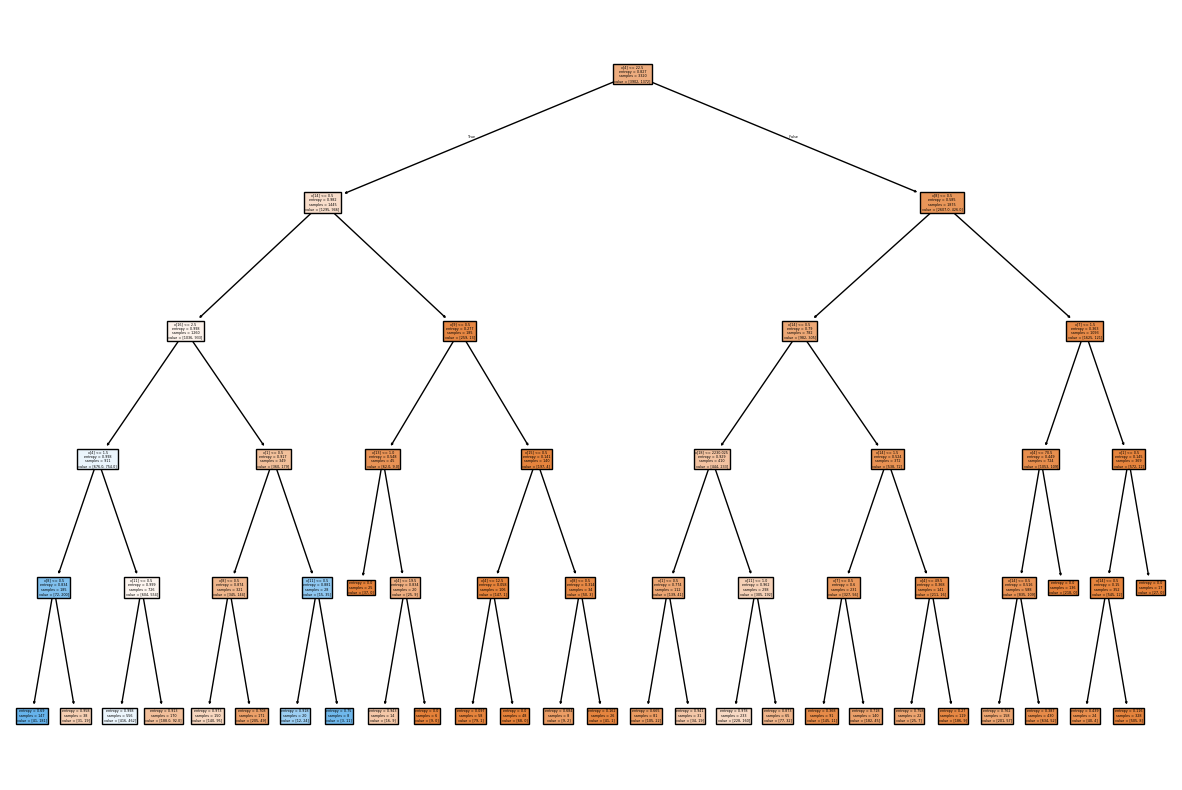

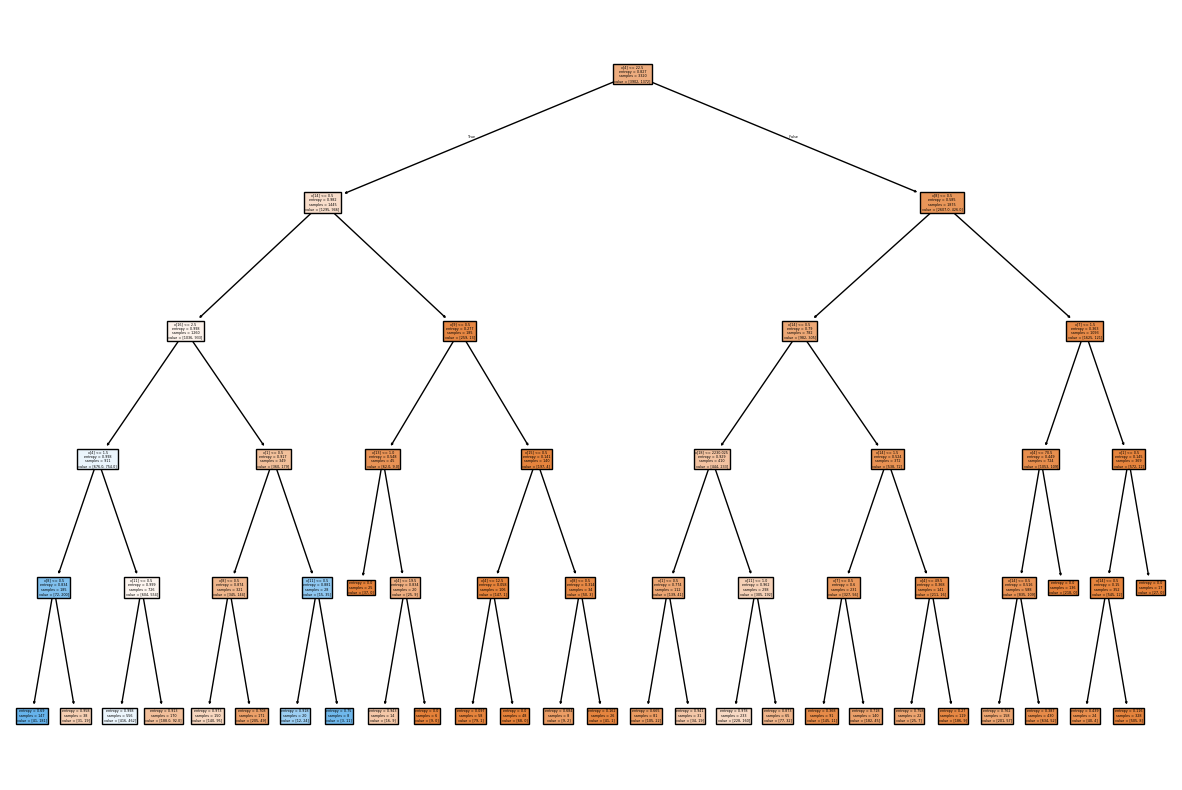

In [66]:
#Showing the 1st tree out of 100 trees
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(modell.estimators_[0],filled=True)
plt.show()